In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('superstore_dataset.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())


Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Data Cleaning

Checked for duplicates and missing values before applying any cleaning steps — this is standard practice, since you shouldn't clean data you haven't actually inspected. Result: **0 duplicate rows and 0 missing values across all 21 columns.** This is a well-curated sample dataset, so no imputation, dropping, or filling was necessary. No `Postal Code` gaps to handle either (unlike the template's example), since this data is already complete.

In [4]:
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head())

      Sales    Profit  Profit Margin  Order Year  Order Month
0  261.9600   41.9136          16.00        2016           11
1  731.9400  219.5820          30.00        2016           11
2   14.6200    6.8714          47.00        2016            6
3  957.5775 -383.0310         -40.00        2015           10
4   22.3680    2.5164          11.25        2015           10


In [5]:
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display


In [6]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 2 — Time-Series Trend Analysis

In [ ]:
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                  marker='o', linewidth=2, markersize=4)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Order Month-Year'].dt.to_timestamp(), category_data['Sales'],
                  marker='o', linewidth=2, markersize=4)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

Sales show clear seasonality — a dip in early months (Jan-Feb) each year, followed by a sharp spike toward year-end (Nov-Dec), likely holiday-driven. Overall trend is upward: each year's peak exceeds the last, from ~$82K in 2014 to ~$119K in 2017.

## Geographic Sales Performance

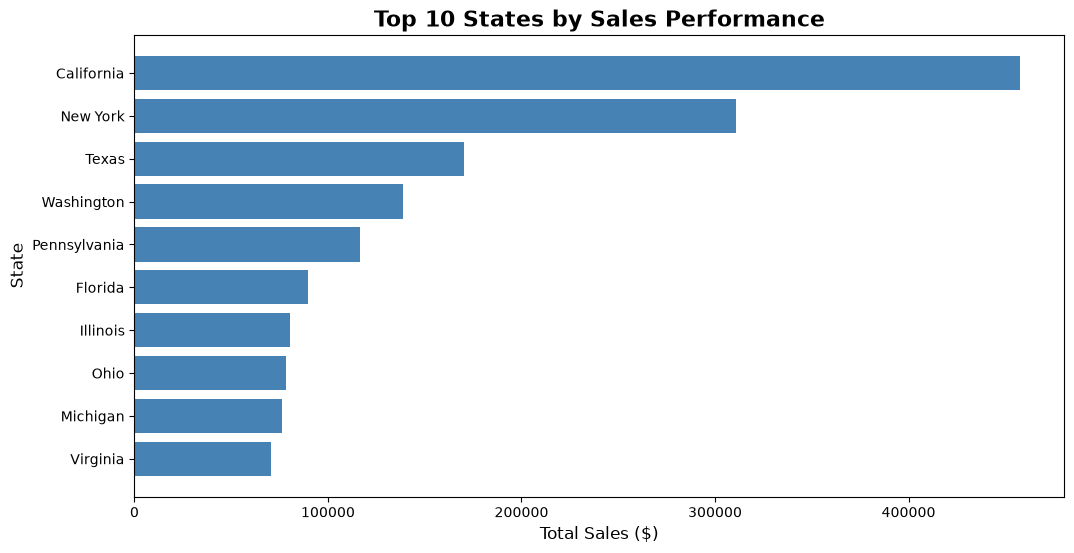

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

In [8]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))
    top_states = state_sales.tail(top_n)

    plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values()) * 0.01, i, f'${value:,.0f}',
                  va='center', fontsize=10)

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Top {top_n} states represent: ${top_states.sum():,.0f} in sales")

top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

## Part 3 — Top 10 Most Profitable Products

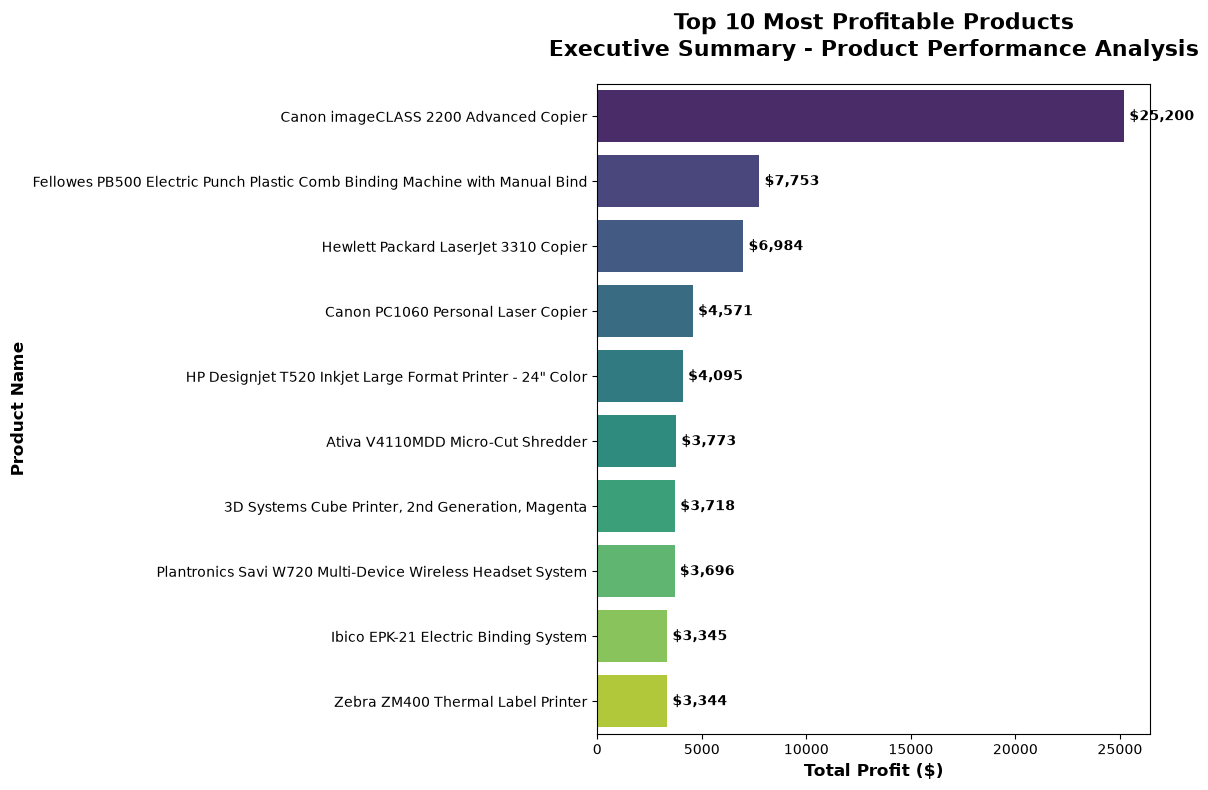

In [10]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index, hue=product_profit.index, palette='viridis', legend=False)

plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

max_profit = product_profit.values.max()
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + max_profit * 0.01, i, f'${profit:,.0f}',
             va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

The Canon imageCLASS 2200 Advanced Copier is by far the most profitable product ($25,200) — more than 3x the second-place item ($7,753). The remaining top 10 cluster fairly evenly between $3,300-$7,700, showing profit here is concentrated in a small number of high-value items rather than spread evenly.

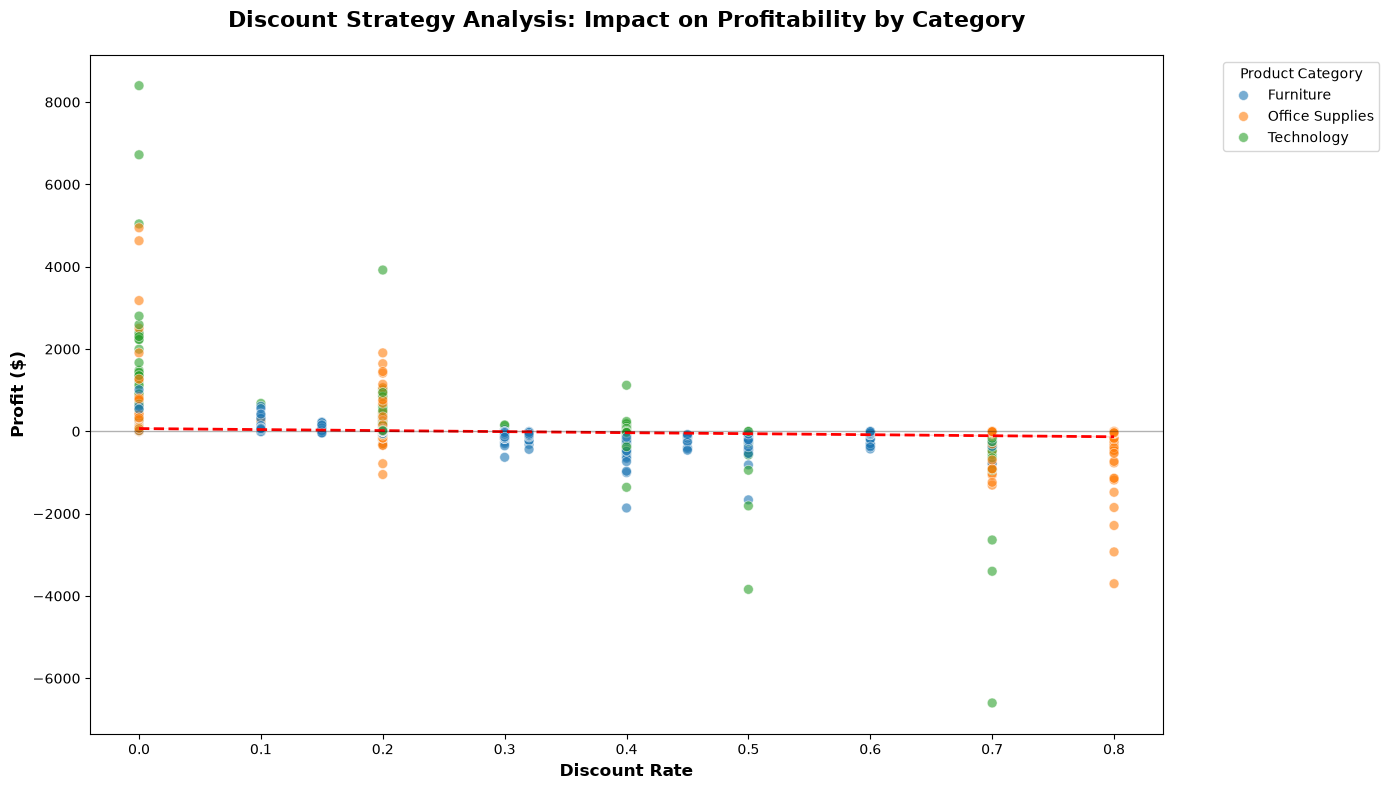

Transactions with >20% discount: 1,393
Average profit for high discounts: $-97.18
Percentage of high-discount sales with losses: 96.8%


In [11]:
plt.figure(figsize=(14, 8))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Discount Strategy Analysis: Impact on Profitability by Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)

plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

high_discount = df[df['Discount'] > 0.2]
print(f"Transactions with >20% discount: {len(high_discount):,}")
print(f"Average profit for high discounts: ${high_discount['Profit'].mean():.2f}")
print(f"Percentage of high-discount sales with losses: {(high_discount['Profit'] < 0).mean()*100:.1f}%")

In [12]:
print("Category-specific discount impact:")
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_loss = high_disc_cat['Profit'].mean()
        print(f"• {category}: Average profit at >20% discount = ${avg_loss:.2f}")

Category-specific discount impact:
• Furniture: Average profit at >20% discount = $-100.51
• Office Supplies: Average profit at >20% discount = $-69.32
• Technology: Average profit at >20% discount = $-197.42


**Critical finding:** Discounts above 20% correlate strongly with losses across the board. 96.8% of transactions with >20% discount result in a loss, averaging -$97.18. The effect is worst in **Technology** (avg -$197.42), followed by Furniture (-$100.51) and Office Supplies (-$69.32). This suggests a 20% discount threshold is roughly where profitability breaks down, and Technology products are the most sensitive to aggressive discounting.

## Part 4 — Methodology and Tooling Review

**Matplotlib strengths (demonstrated above):**
- Fine-grained control over interactive widgets (the dropdown and slider charts)
- Precise, manual placement of annotations (the dollar-value labels on the product chart)
- Full control over figure sizing and layout

**Seaborn strengths (demonstrated above):**
- Built-in statistical visualizations (the regression trend line in the discount chart)
- Automatic legends and color palettes with minimal code
- Clean, professional default styling suited to executive presentations

**Recommendation:** For rapid exploration, use Matplotlib — it integrates seamlessly with interactive widgets for dynamic, iterative analysis. For stakeholder-facing presentations, use Seaborn — its built-in statistical functionality and polished default aesthetics make findings easier to communicate clearly.

In [13]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
top5_share = (state_sales.tail(5).sum() / total_sales) * 100

top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]

print(f"Total Revenue: ${total_sales:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Overall Profit Margin: {profit_margin:.1f}%")
print(f"Top state: {top_state} (${top_state_sales:,.0f})")
print(f"Top 5 states share: {top5_share:.1f}%")
print(f"Leading category: {top_category}")
print(f"Most profitable product: {product_profit.index[0]}")

Total Revenue: $2,297,201
Total Profit: $286,397
Overall Profit Margin: 12.5%
Top state: California ($457,688)
Top 5 states share: 52.0%
Leading category: Technology
Most profitable product: Canon imageCLASS 2200 Advanced Copier


## Part 5 — Executive Summary

**Business Performance**
- Total Revenue: $2,297,201 | Total Profit: $286,397 | Overall Profit Margin: 12.5%

**Geographic Performance**
- California is the top state by far ($457,688 in sales), and the top 5 states together account for 52.0% of total revenue — sales are highly concentrated rather than evenly distributed nationally.

**Product Performance**
- Technology is the leading category by revenue, and the Canon imageCLASS 2200 Advanced Copier is the single most profitable product ($25,200) — over 3x the next-best item.

**Discount Strategy Risk**
- Discounts above 20% correlate with losses on 96.8% of transactions (avg. -$97.18/sale). Technology is the most discount-sensitive category (avg. -$197.42 at >20% discount).

**Recommendation:** Limit standard discounts to 20% or below to protect profitability, with extra scrutiny on Technology products given their outsized loss exposure at high discount levels. Consider concentrating marketing/inventory investment around top-performing states (CA, NY) while exploring underperforming regions for growth opportunities.